## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import itertools
import os
import glob

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping #Va nous permettre d'éviter l'overfitting

## Chargement des données


In [3]:
from google.colab import drive
drive.mount('/content/drive')
import os
import glob
import numpy as np

dossier = "/content/drive/MyDrive/redshift"
os.chdir(dossier)

# Lister tous les fichiers .npz du dossier
npz_files = glob.glob("*.npz")

# Filtrer uniquement les fichiers contenant "COSMOS"
cosmos_files = [f for f in npz_files if "COSMOS" in f]

# Charger chaque fichier dans un dictionnaire séparé
cosmos_data = {}
for fichier in cosmos_files:
    try:
        cosmos_data[fichier] = np.load(fichier, allow_pickle=True)
        print(f"Chargé : {fichier}")
    except Exception as e:
        print(f"Erreur lors du chargement de {fichier} : {e}")

# Afficher les clés et les shapes de chaque fichier séparément
for nom, data in cosmos_data.items():
    print(f"\n=== {nom} ===")
    for key in data.keys():
        print(f"  - {key} : {data[key].shape}")

# Séparer les fichiers COSMOS en deux groupes : spec et phot
spec_files = [f for f in cosmos_files if "spec" in f.lower()]
phot_files = [f for f in cosmos_files if "phot" in f.lower()]

print("Fichiers SPEC:", spec_files)
print("Fichiers PHOT:", phot_files)

# Charger les données spec
spec_data = np.load(spec_files[0], allow_pickle=True)

# Charger les données phot
phot_data = np.load(phot_files[0], allow_pickle=True)

# Extraire les infos
spec_info = spec_data["info"]
phot_info = phot_data["info"]

# Convertir en DataFrame pandas
spec_df = pd.DataFrame(spec_info)
phot_df = pd.DataFrame(phot_info)

# Renommer les colonnes cibles
spec_df = spec_df.rename(columns={"ZSPEC": "redshift"})
phot_df = phot_df.rename(columns={"ZPHOT": "redshift"})

# Vérifier
print("Colonnes SPEC:", spec_df.columns.tolist())
print("Colonnes PHOT:", phot_df.columns.tolist())

# Garder uniquement les magnitudes
magnitudes = ['u', 'g', 'r', 'i', 'z', 'y', 'EBV']

spec_mag = spec_df[magnitudes + ['redshift']].copy()
phot_mag = phot_df[magnitudes + ['redshift']].copy()

# Créer les couleurs
for df in [spec_mag, phot_mag]:
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['z_y'] = df['z'] - df['y']

# Filtrer les données
#spec_mag = spec_mag[spec_mag['redshift'] <= 1].copy()
#phot_mag = phot_mag[phot_mag['redshift'] <= 1].copy()

# Nettoyage des -99
magnitudes = ['u', 'g', 'r', 'i', 'z', 'y', 'EBV']
#for df_name, df in [('spec_mag', spec_mag), ('phot_mag', phot_mag)]:
    #df.replace(-99, np.nan, inplace=True)
    #for col in magnitudes:
        #df.loc[df[col] < -90, col] = np.nan

spec_mag = spec_mag.dropna(subset=magnitudes).copy()
phot_mag = phot_mag.dropna(subset=magnitudes).copy()

# Recalculer les couleurs après nettoyage
for df in [spec_mag, phot_mag]:
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['z_y'] = df['z'] - df['y']

print(f"SPEC après nettoyage : {len(spec_mag)} objets")
print(f"PHOT après nettoyage : {len(phot_mag)} objets")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Chargé : COSMOS_v11_uijk_0001_photo_D.npz
Chargé : COSMOS_v11_uijk_0213_photo_UD.npz
Chargé : COSMOS_v11_uijk_0020_spec_D.npz
Chargé : COSMOS_v11_uijk_0073_spec_UD.npz

=== COSMOS_v11_uijk_0001_photo_D.npz ===
  - cube : (12054, 64, 64, 9)
  - info : (12054,)
  - flag : (12054, 9)

=== COSMOS_v11_uijk_0213_photo_UD.npz ===
  - cube : (443, 64, 64, 9)
  - info : (443,)
  - flag : (443, 9)

=== COSMOS_v11_uijk_0020_spec_D.npz ===
  - cube : (15, 64, 64, 9)
  - info : (15,)
  - flag : (15, 9)

=== COSMOS_v11_uijk_0073_spec_UD.npz ===
  - cube : (12, 64, 64, 9)
  - info : (12,)
  - flag : (12, 9)
Fichiers SPEC: ['COSMOS_v11_uijk_0020_spec_D.npz', 'COSMOS_v11_uijk_0073_spec_UD.npz']
Fichiers PHOT: ['COSMOS_v11_uijk_0001_photo_D.npz', 'COSMOS_v11_uijk_0213_photo_UD.npz']
Colonnes SPEC: ['ID', 'RA', 'DEC', 'TRACT', 'PATCH', 'MASK', 'FLAG_FIELD', 'EB_V', 'CLASS_STAR_

## Préparation des données images pour le CNN

In [4]:
# Normalisation des images 

def custom_norm(x):
    return np.sign(x) * np.sqrt(np.abs(x) + 1) - 1

# Données d'entraînement

X_train = custom_norm(phot_data['cube'].astype(np.float32))
y_train = phot_info['ZPHOT'].astype(np.float32)

# Nettoyage ZPHOT

mask_phot = np.isfinite(y_train) & (y_train > 0)
X_train   = X_train[mask_phot]
y_train   = y_train[mask_phot]

print(f"Train (phot) : {X_train.shape[0]} objets  |  shape image : {X_train.shape[1:]}")

# Les données spec vont nous servir de vérité terrain

X_spec_list = []
y_spec_list = []

for f in spec_files:
    d    = cosmos_data[f]
    info = pd.DataFrame(d['info'])
    zs   = info['ZSPEC'].values.astype(np.float32)
    cube = d['cube'].astype(np.float32)

    mask = np.isfinite(zs) & (zs > 0)
    X_spec_list.append(custom_norm(cube[mask]))
    y_spec_list.append(zs[mask])

X_spec = np.concatenate(X_spec_list, axis=0)
y_spec = np.concatenate(y_spec_list, axis=0)

print(f"Spec total   : {X_spec.shape[0]} objets  |  shape image : {X_spec.shape[1:]}")

# Split spec calib / test
X_calib, X_test, y_calib, y_test = train_test_split(
    X_spec, y_spec, test_size=0.5, random_state=42
)

print(f"Calibration  : {X_calib.shape[0]} objets")
print(f"Test         : {X_test.shape[0]} objets")

Train (phot) : 12054 objets  |  shape image : (64, 64, 9)
Spec total   : 27 objets  |  shape image : (64, 64, 9)
Calibration  : 13 objets
Test         : 14 objets


## Architecture et entraînement du CNN

CNN entraîné sur les images phot, avec EarlyStopping pour éviter l'overfitting.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,617 (436.00 KB)

 Trainable params: 111,617 (436.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 97s 279ms/step - loss: 0.8239 - mae: 0.7009 - val_loss: 0.9293 - val_mae: 0.7758
Epoch 2/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 100s 296ms/step - loss: 0.7830 - mae: 0.6843 - val_loss: 0.8345 - val_mae: 0.6844
Epoch 3/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 141s 293ms/step - loss: 0.7550 - mae: 0.6703 - val_loss: 0.8472 - val_mae: 0.6777
Epoch 4/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 104s 308ms/step - loss: 0.7402 - mae: 0.6623 - val_loss: 0.8279 - val_mae: 0.6711
Epoch 5/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 132s 279ms/step - loss: 0.7320 - mae: 0.6573 - val_loss: 0.8041 - val_mae: 0.6691
Epoch 6/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 95s 281ms/step - loss: 0.7170 - mae: 0.6499 - val_loss: 0.8020 - val_mae: 0.6627
Epoch 7/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 146s 292ms/step - loss: 0.7102 - mae: 0.6458 - val_loss: 0.7761 - val_mae: 0.6766
Epoch 8/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 94s 276ms/step - loss: 0.6886 - mae: 0.6371 - val_loss: 0.7864 - val_mae: 0.6921
Epoch 9/30
339/339 ━━━━━━━━

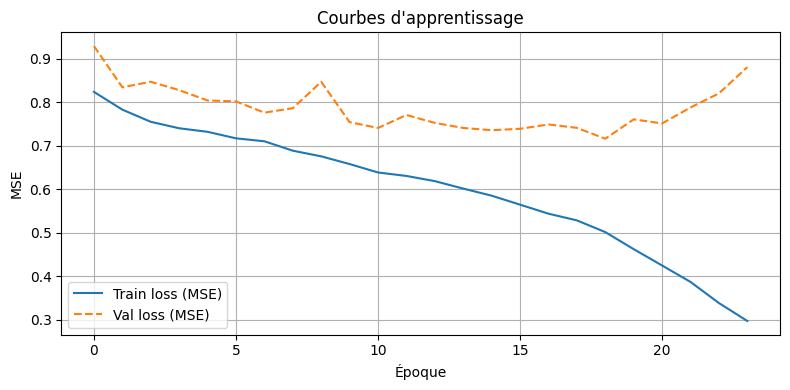

In [5]:
model = models.Sequential([
    layers.Input(shape=(64, 64, 9)),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1) 
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# Entraînement

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Courbe d'apprentissage

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Train loss (MSE)')
plt.plot(history.history['val_loss'], label='Val loss (MSE)', linestyle='--')
plt.xlabel("Époque"); plt.ylabel("MSE")
plt.title("Courbes d'apprentissage")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

── Métriques CNN sur données spec ──────────────────────
  N objets spec      : 27
  MAE (Δz brut)      : 1.3303
  Biais              : 0.1824
  NMAD               : 0.6563
  Taux outliers η    : 0.852  (|Δz/(1+z)| > 0.15)


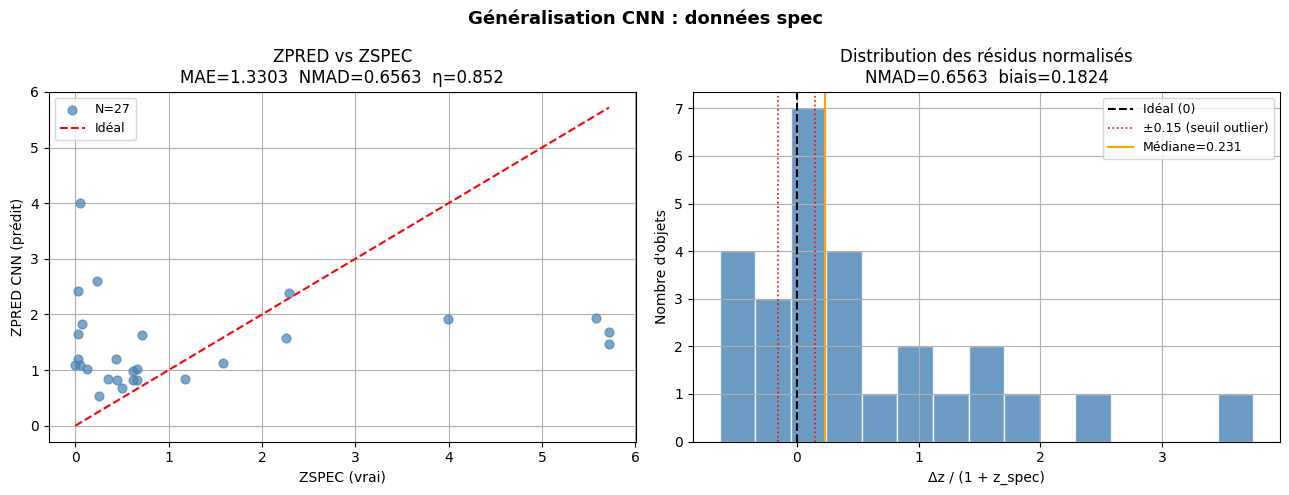

In [6]:
# Evaluation du CNN sur les données spec

# Prédictions sur tout le set spec (calib + test)

z_pred_all = model.predict(X_spec, verbose=0).squeeze()
z_true_all = y_spec

dz_norm = (z_pred_all - z_true_all) / (1 + z_true_all)
mae     = np.mean(np.abs(z_pred_all - z_true_all))
bias    = np.mean(z_pred_all - z_true_all)
nmad    = 1.4826 * np.median(np.abs(dz_norm - np.median(dz_norm)))
eta     = np.mean(np.abs(dz_norm) > 0.15)

print(" Métriques CNN sur données spec ")
print(f"  N objets spec      : {len(z_true_all)}")
print(f"  MAE (Δz brut)      : {mae:.4f}")
print(f"  Biais              : {bias:.4f}")
print(f"  NMAD               : {nmad:.4f}")
print(f"  Taux outliers η    : {eta:.3f}  (|Δz/(1+z)| > 0.15)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Généralisation CNN : données spec", fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(z_true_all, z_pred_all, s=40, alpha=0.7, color='steelblue', zorder=3, label=f"N={len(z_true_all)}")
zmax = max(z_true_all.max(), z_pred_all.max())
ax.plot([0, zmax], [0, zmax], 'r--', lw=1.5, label='Idéal')
ax.set_xlabel("ZSPEC (vrai)")
ax.set_ylabel("ZPRED CNN (prédit)")
ax.set_title(f"ZPRED vs ZSPEC\nMAE={mae:.4f}  NMAD={nmad:.4f}  η={eta:.3f}")
ax.legend(fontsize=9); ax.grid(True)

ax = axes[1]
ax.hist(dz_norm, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0,     color='black', lw=1.5, ls='--', label='Idéal (0)')
ax.axvline( 0.15, color='red',   lw=1.2, ls=':',  label='±0.15 (seuil outlier)')
ax.axvline(-0.15, color='red',   lw=1.2, ls=':')
ax.axvline(np.median(dz_norm), color='orange', lw=1.5, label=f"Médiane={np.median(dz_norm):.3f}")
ax.set_xlabel("Δz / (1 + z_spec)")
ax.set_ylabel("Nombre d'objets")
ax.set_title(f"Distribution des résidus normalisés\nNMAD={nmad:.4f}  biais={bias:.4f}")
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.show()


## Prédictions CNN sur les images spec

In [7]:
# Prédictions sur le set de calibration et le set de test

z_pred_calib = model.predict(X_calib, verbose=0).squeeze()
z_pred_test  = model.predict(X_test,  verbose=0).squeeze()

# Vérité terrain

z_true_calib = y_calib
z_true_test  = y_test

print(f"Prédictions calib : {len(z_pred_calib)} objets")
print(f"Prédictions test  : {len(z_pred_test)} objets")
print(f"ZPRED calib → min={z_pred_calib.min():.3f}  max={z_pred_calib.max():.3f}")
print(f"ZSPEC calib → min={z_true_calib.min():.3f}  max={z_true_calib.max():.3f}")

# Niveaux de confiance à tester

alphas = [0.05, 0.10, 0.15, 0.20]

Prédictions calib : 13 objets
Prédictions test  : 14 objets
ZPRED calib → min=0.163  max=1.979
ZSPEC calib → min=0.052  max=5.720


## Première approche — Résidus directs  |ZPRED − ZSPEC|

Correspondant au score de non-conformité, résidu absolu entre la prédiction CNN et la vérité ZSPEC

In [8]:
print("APPROCHE 1 : Résidus directs  |ZPRED - ZSPEC|")

scores_1 = np.abs(z_pred_calib - z_true_calib)

results_1 = {}
print(f"\n{'α':>6} | {'q_hat':>8} | {'Couverture':>12} | {'Largeur':>10}")
print("-" * 45)
for alpha in alphas:
    q     = np.quantile(scores_1, 1 - alpha)
    low   = z_pred_test - q
    high  = z_pred_test + q
    cov   = np.mean((z_true_test >= low) & (z_true_test <= high))
    width = 2 * q
    results_1[alpha] = dict(q_hat=q, coverage=cov, width=width, lower=low, upper=high)
    print(f"{alpha:>6.2f} | {q:>8.4f} | {cov:>12.3f} | {width:>10.4f}")

APPROCHE 1 : Résidus directs  |ZPRED - ZSPEC|

     α |    q_hat |   Couverture |    Largeur
---------------------------------------------
  0.05 |   2.8811 |        0.857 |     5.7621
  0.10 |   1.9357 |        0.857 |     3.8713
  0.15 |   1.7100 |        0.857 |     3.4200
  0.20 |   1.4826 |        0.857 |     2.9652


## Deuxième approche — Bins de redshift (largeur 0.1)

On discrétise z en bins de largeur 0.1 et on mesure l'écart en nombre de bins
entre la prédiction CNN et la vérité ZSPEC.

In [9]:
print("APPROCHE 2 : Bins de redshift (largeur 0.1)")

bins   = np.arange(0, 4.1, 0.1)
n_bins = len(bins) - 1

def to_bin(z):
    return np.clip(np.digitize(z, bins) - 1, 0, n_bins - 1)

scores_2 = np.abs(to_bin(z_pred_calib) - to_bin(z_true_calib))

results_2 = {}
print(f"\n{'α':>6} | {'k_hat':>8} | {'Couverture':>12} | {'Largeur Δz':>12}")
print("-" * 48)
for alpha in alphas:
    k     = int(np.ceil(np.quantile(scores_2, 1 - alpha)))
    b_p   = to_bin(z_pred_test)
    low_b = np.clip(b_p - k, 0, n_bins - 1)
    hig_b = np.clip(b_p + k, 0, n_bins - 1)
    low   = bins[low_b]
    high  = bins[np.minimum(hig_b + 1, n_bins)]
    cov   = np.mean((z_true_test >= low) & (z_true_test <= high))
    width = np.mean(high - low)
    results_2[alpha] = dict(k_hat=k, coverage=cov, width=width, lower=low, upper=high)
    print(f"{alpha:>6.2f} | {k:>8d} | {cov:>12.3f} | {width:>12.4f}")

APPROCHE 2 : Bins de redshift (largeur 0.1)

     α |    k_hat |   Couverture |   Largeur Δz
------------------------------------------------
  0.05 |       22 |        0.857 |       3.0357
  0.10 |       20 |        0.857 |       2.8500
  0.15 |       17 |        0.857 |       2.5357
  0.20 |       15 |        0.857 |       2.2929


## Troisième approche — Δz normalisé  (z_pred − z_spec) / (1 + z_spec)

Score standard en astronomie pour les photo-z.
Normalise l'erreur par (1 + z) pour tenir compte de l'expansion cosmique.

In [10]:
print("APPROCHE 3 : Δz = (ZPRED - ZSPEC) / (1 + ZSPEC)")

scores_3 = np.abs((z_pred_calib - z_true_calib) / (1 + z_true_calib))

results_3 = {}
print(f"\n{'α':>6} | {'q_hat':>8} | {'Couverture':>12} | {'Outliers':>10}")
print("-" * 45)
for alpha in alphas:
    q    = np.quantile(scores_3, 1 - alpha)
    dz   = np.abs((z_pred_test - z_true_test) / (1 + z_true_test))
    cov  = np.mean(dz <= q)
    out  = np.mean(dz > 0.15)
    low  = z_pred_test - q * (1 + z_true_test)
    high = z_pred_test + q * (1 + z_true_test)
    results_3[alpha] = dict(q_hat=q, coverage=cov, outliers=out,
                            dz_test=dz, lower=low, upper=high)
    print(f"{alpha:>6.2f} | {q:>8.4f} | {cov:>12.3f} | {out:>10.3f}")

APPROCHE 3 : Δz = (ZPRED - ZSPEC) / (1 + ZSPEC)

     α |    q_hat |   Couverture |   Outliers
---------------------------------------------
  0.05 |   0.9052 |        0.929 |      0.571
  0.10 |   0.5950 |        0.929 |      0.571
  0.15 |   0.5111 |        0.786 |      0.571
  0.20 |   0.4557 |        0.786 |      0.571


## Figures — Comparaison des 3 approches

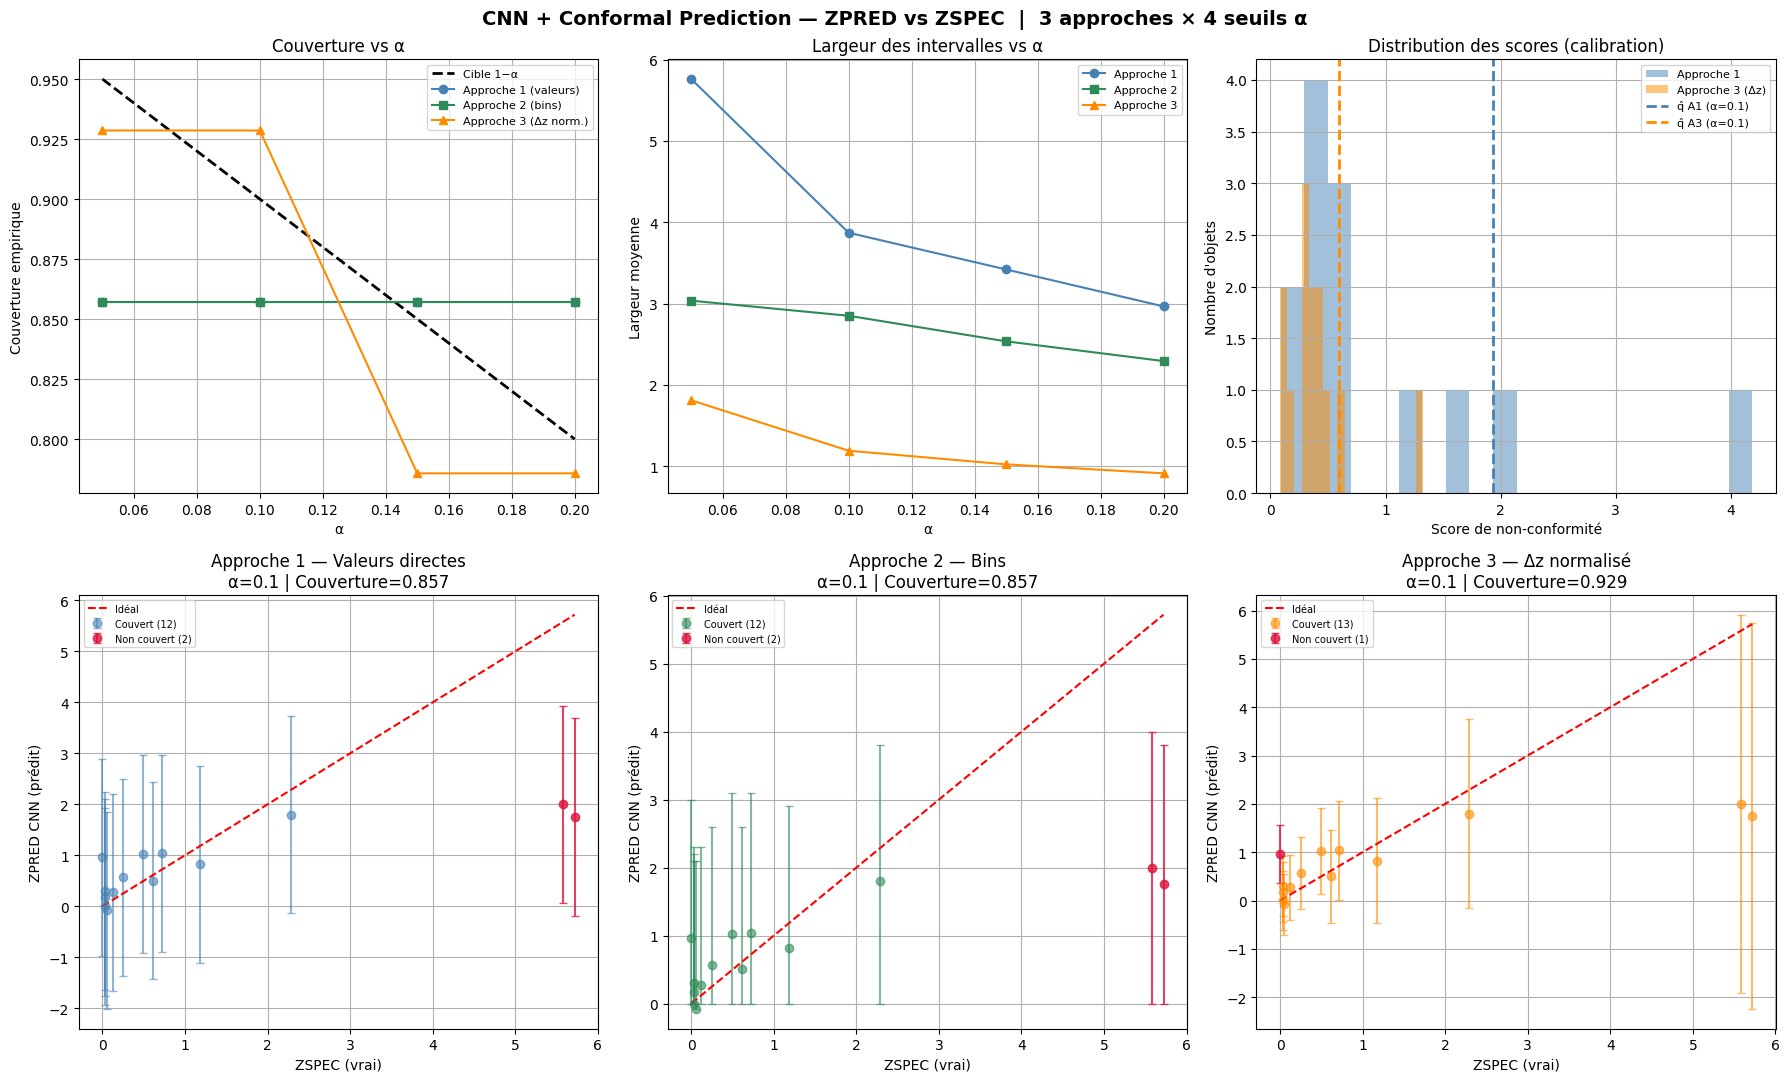

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "CNN + Conformal Prediction — ZPRED vs ZSPEC, 3 approches × 4 seuils α",
    fontsize=14, fontweight='bold'
)

alpha_ref = 0.10

# Ligne 1 : métriques globales

# (0,0) Couverture vs α

ax = axes[0, 0]
cov1 = [results_1[a]['coverage'] for a in alphas]
cov2 = [results_2[a]['coverage'] for a in alphas]
cov3 = [results_3[a]['coverage'] for a in alphas]
ax.plot(alphas, [1 - a for a in alphas], 'k--', lw=2, label='Cible 1−α')
ax.plot(alphas, cov1, 'o-', color='steelblue',  label='Approche 1 (valeurs)')
ax.plot(alphas, cov2, 's-', color='seagreen',   label='Approche 2 (bins)')
ax.plot(alphas, cov3, '^-', color='darkorange', label='Approche 3 (Δz norm.)')
ax.set_xlabel("α"); ax.set_ylabel("Couverture empirique")
ax.set_title("Couverture vs α")
ax.legend(fontsize=8); ax.grid(True)

# (0,1) Largeur des intervalles vs α

ax = axes[0, 1]
w1 = [results_1[a]['width']     for a in alphas]
w2 = [results_2[a]['width']     for a in alphas]
w3 = [results_3[a]['q_hat'] * 2 for a in alphas]
ax.plot(alphas, w1, 'o-', color='steelblue',  label='Approche 1')
ax.plot(alphas, w2, 's-', color='seagreen',   label='Approche 2')
ax.plot(alphas, w3, '^-', color='darkorange', label='Approche 3')
ax.set_xlabel("α"); ax.set_ylabel("Largeur moyenne")
ax.set_title("Largeur des intervalles vs α")
ax.legend(fontsize=8); ax.grid(True)

# (0,2) Distribution des scores de calibration

ax = axes[0, 2]
ax.hist(scores_1, bins=20, alpha=0.5, color='steelblue',  label='Approche 1')
ax.hist(scores_3, bins=20, alpha=0.5, color='darkorange', label='Approche 3 (Δz)')
ax.axvline(results_1[alpha_ref]['q_hat'], color='steelblue',  ls='--', lw=2,
           label=f"q̂ A1 (α={alpha_ref})")
ax.axvline(results_3[alpha_ref]['q_hat'], color='darkorange', ls='--', lw=2,
           label=f"q̂ A3 (α={alpha_ref})")
ax.set_xlabel("Score de non-conformité")
ax.set_ylabel("Nombre d'objets")
ax.set_title("Distribution des scores (calibration)")
ax.legend(fontsize=8); ax.grid(True)

# Ligne 2 : ZPRED vs ZSPEC pour chaque approche (α=0.10)

configs = [
    (results_1, "Approche 1 — Valeurs directes", "steelblue"),
    (results_2, "Approche 2 — Bins",             "seagreen"),
    (results_3, "Approche 3 — Δz normalisé",     "darkorange"),
]
for col_idx, (results, label, color) in enumerate(configs):
    ax  = axes[1, col_idx]
    r   = results[alpha_ref]
    low, high = r['lower'], r['upper']
    covered   = (z_true_test >= low) & (z_true_test <= high)
    yerr = np.array([
        np.maximum(z_pred_test - low, 0),
        np.maximum(high - z_pred_test, 0)
        ])


    ax.errorbar(
        z_true_test[covered],  z_pred_test[covered],
        yerr=[yerr[0][covered],  yerr[1][covered]],
        fmt='o', alpha=0.6, capsize=3, color=color,
        label=f'Couvert ({covered.sum()})'
    )
    ax.errorbar(
        z_true_test[~covered], z_pred_test[~covered],
        yerr=[yerr[0][~covered], yerr[1][~covered]],
        fmt='o', alpha=0.8, capsize=3, color='crimson',
        label=f'Non couvert ({(~covered).sum()})'
    )
    zmax = max(z_true_test.max(), z_pred_test.max())
    ax.plot([0, zmax], [0, zmax], 'r--', lw=1.5, label='Idéal')
    ax.set_xlabel("ZSPEC (vrai)"); ax.set_ylabel("ZPRED CNN (prédit)")
    ax.set_title(f"{label}\nα={alpha_ref} | Couverture={r['coverage']:.3f}")
    ax.legend(fontsize=7); ax.grid(True)

plt.tight_layout()
plt.show()

## Tableau récapitulatif

In [ ]:
print("Tableau récapitulatif — CNN + Conformal Prediction")

print(f"{'Approche':<30} {'α':>5} | {'Cible':>7} | {'Couverture':>11} | {'Largeur':>9}")
print("-" * 65)
for alpha in alphas:
    print(f"{'Valeurs directes':<30} {alpha:>5.2f} | {1-alpha:>7.2f} | "
          f"{results_1[alpha]['coverage']:>11.3f} | {results_1[alpha]['width']:>9.4f}")
print()
for alpha in alphas:
    print(f"{'Bins (Δz=0.1)':<30} {alpha:>5.2f} | {1-alpha:>7.2f} | "
          f"{results_2[alpha]['coverage']:>11.3f} | {results_2[alpha]['width']:>9.4f}")
print()
for alpha in alphas:
    dz_sigma = 1.4826 * np.median(np.abs(
        results_3[alpha]['dz_test'] - np.median(results_3[alpha]['dz_test'])
    ))
    print(f"{'Δz normalisé':<30} {alpha:>5.2f} | {1-alpha:>7.2f} | "
          f"{results_3[alpha]['coverage']:>11.3f} | {results_3[alpha]['q_hat']:>9.4f}  "
          f"(σ_NMAD={dz_sigma:.4f}  outliers={results_3[alpha]['outliers']:.3f})")


TABLEAU RÉCAPITULATIF — CNN + Conformal Prediction
Approche                           α |   Cible |  Couverture |   Largeur
-----------------------------------------------------------------
Valeurs directes                0.05 |    0.95 |       0.857 |    6.3970
Valeurs directes                0.10 |    0.90 |       0.786 |    4.5908
Valeurs directes                0.15 |    0.85 |       0.714 |    3.5251
Valeurs directes                0.20 |    0.80 |       0.714 |    2.9519

Bins (Δz=0.1)                   0.05 |    0.95 |       0.857 |    3.7571
Bins (Δz=0.1)                   0.10 |    0.90 |       0.786 |    3.6214
Bins (Δz=0.1)                   0.15 |    0.85 |       0.714 |    3.1357
Bins (Δz=0.1)                   0.20 |    0.80 |       0.714 |    2.7929

Δz normalisé                    0.05 |    0.95 |       0.714 |    1.2492  (σ_NMAD=0.5053  outliers=0.857)
Δz normalisé                    0.10 |    0.90 |       0.714 |    1.1688  (σ_NMAD=0.5053  outliers=0.857)
Δz normalis